# Evaluation of the generated reviews (Few-Shot examples)

## Load Dataset

In [2]:
from pathlib import Path

ROOT = Path.cwd()
DATA_DIR = ROOT / "data" / "few-shot"
DATA_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
import json
import pandas as pd

dfs = []

for file_path in DATA_DIR.glob("*.json"):
  with open(file_path, "r", encoding="utf-8") as f:
    print(f"Loading '{file_path.stem}'...")
    data = json.load(f)
    df = pd.DataFrame(data["reviews"])
    df["total_reviews"] = data["total_reviews"]
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

Loading 'llama3.1_latest_reviews'...
Loading 'mistral_latest_reviews'...
Loading 'codellama_latest_reviews'...
Loading 'qwen2.5-coder_32b_reviews'...


In [4]:
combined_df.sample(5)

,model,restaurant,category,ai_rating,human_rating,keywords,ai_review,human_review,word_count,total_reviews
890,mistral:latest,Diners Pavilion,General,3.0,1,"['plates', 'request', 'seen']",The dining experience at Diners Pavilion was p...,worst service ever seen bug in food cold food ...,49,500
380,llama3.1:latest,Biryanis And More,Indian,4.0,1,"['biryani', 'tikka', 'paneer']",ordered the Hyderabadi biryani which was cooke...,having heard a lot about this place specially ...,47,500
90,llama3.1:latest,Owm Nom Nom,General,2.0,1,"['sorry', 'oily', 'bland']",walked into owm nom nom expecting a culinary a...,painfully slow delivery exceedingly oily and b...,59,500
1859,qwen2.5-coder:32b,Diners Pavilion,General,2.0,1,"['plates', 'request', 'seen']",I made a specific request for a gluten-free di...,worst service ever seen bug in food cold food ...,49,500
948,mistral:latest,Chinese Pavilion,Chinese,5.0,4,"['amazing', 'really', 'chocolate']",The Chinese Pavilion truly lived up to its nam...,i was told by one of my colleague about this p...,57,500


In [5]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   model          1969 non-null   object 
 1   restaurant     1969 non-null   object 
 2   category       1969 non-null   object 
 3   ai_rating      1969 non-null   float64
 4   human_rating   1969 non-null   int64  
 5   keywords       1969 non-null   object 
 6   ai_review      1969 non-null   object 
 7   human_review   1969 non-null   object 
 8   word_count     1969 non-null   int64  
 9   total_reviews  1969 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 154.0+ KB


In [6]:
combined_df.rename(columns={"ai_review": "gen_review"}, inplace=True)

In [7]:
combined_df_deduplicated = combined_df.groupby(['category', 'keywords', 'model']).apply(lambda x: x.sample(n=1, random_state=42)).reset_index(drop=True)
print(f"Original DataFrame size: {len(combined_df)}")
print(f"Deduplicated DataFrame size: {len(combined_df_deduplicated)}")
combined_df = combined_df_deduplicated
print(combined_df.shape)

Original DataFrame size: 1969
Deduplicated DataFrame size: 200
(200, 10)


/tmp/ipython-input-2832734445.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined_df_deduplicated = combined_df.groupby(['category', 'keywords', 'model']).apply(lambda x: x.sample(n=1, random_state=42)).reset_index(drop=True)


In [8]:
combined_df.model.unique()

array(['codellama:latest', 'llama3.1:latest', 'mistral:latest',
       'qwen2.5-coder:32b'], dtype=object)

In [9]:
combined_df.model.value_counts()

,count
model,
codellama:latest,50
llama3.1:latest,50
mistral:latest,50
qwen2.5-coder:32b,50


In [10]:
combined_df.restaurant.unique()

array(['Komatose - Holiday Inn Express & Suites', "Udipi's Upahar",
       'La La Land - Bar & Kitchen', 'SKYHY', 'Chinese Pavilion',
       'Labonel', 'Beyond Flavours', 'Cream Stone', 'eat.fit',
       "Dunkin' Donuts", "GD's", 'Olive Garden', 'Squeeze @ The Lime',
       '10 Downing Street', 'Mustang Terrace Lounge',
       "Sardarji's Chaats & More", '13 Dhaba', 'Al Saba Restaurant',
       'Shah Ghouse Hotel & Restaurant', 'Owm Nom Nom',
       "Zing's Northeast Kitchen", 'Diners Pavilion', 'PourHouse7',
       'Paradise', 'Dine O China', 'Banana Leaf Multicuisine Restaurant',
       'Faasos', 'Pista House', 'Royal Spicy Restaurant',
       'Hyderabadi Daawat', 'Behrouz Biryani', 'Biryanis And More',
       'Khaan Saab', 'KS Bakers', 'Flechazo', 'Frio Bistro',
       'The Glass Onion', "The Fisherman's Wharf",
       "AB's - Absolute Barbecues", 'T Grill'], dtype=object)

In [11]:
combined_df.category.unique()

array(['Bar', 'Chinese', 'Dessert', 'General', 'Indian', 'Italian',
       'Seafood', 'Steakhouse'], dtype=object)

### Clean Generated Review Text

In [12]:
combined_df.gen_review.sample(3).tolist()

["Pista House offers an enjoyable dining experience with its authentic Indian flavors. The chicken dishes were particularly nice, providing a satisfying and aromatic meal that didn't disappoint. Despite being situated 45 minutes from my home, it was worth the journey for the quality of food and pleasant ambiance.",
 "I visited Al Saba Restaurant expecting a decent meal, but what I got was a mixed bag. The portions were generous and the meat dishes were flavorful, especially the shawarma. However, the prices seemed steep given the average quality of food. Overall, it's an okay spot for a quick bite, but don't expect anything too exceptional.",
 'Mr. beyond flavors exceeded expectations by offering a diverse menu that was far from standard fare. The creativity and quality of each dish truly impressed, making it a standout dining experience.']

In [13]:
import re

def clean_generated_review(text: str) -> str:
    if not isinstance(text, str):
        return ""

    original = text


    if "<think>" in text and "</think>" not in text:
        return ""   # mark as empty so the row can later be filtered out


    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL).strip()


    meta_patterns = [
        r"^Here['’]s my attempt.*?:",      # Here’s my attempt...
        r"^Here'?s my attempt at writing .*?review:\s*",
        r"^Here['’]s my review.*?:",       # Here’s my review...
        r"^Here'?s my honest review:\s*",
        r"^Here is my review.*?:",
        r"^\"Here.*?\":",                  # "Here is..."
        r"^Title:.*?\n",                   # Title: ... lines
        r"^Rating:\s*\d.*?\n",             # Rating: 5 etc.
        r"^Okay.*?\n",                     # LLM thinking noise
        r"^Hmm.*?\n",
        r"\*\*\d+(\.\d+)?\/5 stars\*\*\s*",
        r"\*\*.*?\*\*\s*",  # bold titles
        r"\"{2,}",  # repeated quotes
    ]


    for pat in meta_patterns:
        text = re.sub(pat, "", text, flags=re.IGNORECASE | re.DOTALL).strip()


    # Remove extra quotes around the review
    text = text.strip(' "\'')

    # Enforce length constraints (20–500 words)
    word_count = len(text.split())
    if word_count < 20 or word_count > 500:
        return ""


    # If the review contains markdown fences or code-like formatting, remove them
    text = re.sub(r"^```.*?```", "", text, flags=re.DOTALL).strip()

    # Clean repeated whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # keep alphanumeric
    text = re.sub(r'[^a-z0-9\s]', '', text)

    return text.lower().strip()



def clean_dataset(df: pd.DataFrame, review_column: str = "gen_review"):

    df = df.copy()

    # Clean review text
    df[review_column] = df[review_column].apply(clean_generated_review)

    # Remove rows where the generated review is empty or only whitespace
    df = df[df[review_column].str.len() > 10].reset_index(drop=True)

    return df

In [14]:
combined_df = clean_dataset(combined_df)

In [15]:
combined_df.gen_review.sample(3).tolist()

['he desserts at a a and  ar  itchen disappointingly fell short t appears that they do not use highquality ingredients as the flavors were bland and unremarkable espite an inviting ambience  found myself yearning for better tasting treats',
 'he environment at a a and  ar  itchen is kinda rated with a mix of old and new decor that sometimes feels clashing he service is decent but not exceptional which leaves room for improvement verall its a place where you can get by if youre in the area but there are better options out there',
 'recently visited ardarjis haats  ore and the service was terrible hen we arrived there were no staff to greet us and when we tried to order from the menu it was confusing and incomplete he kulcha was bland and overcooked and the combo was not even worth the price  would not recommend this restaurant to anyone']

# Compute evaluation metrics for human vs. generated reviews.

In [16]:
!pip -q install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.4/176.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 37.6 MB/s eta 0:00:00


In [17]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from textstat import flesch_reading_ease
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from transformers import pipeline

# transformers sentiment model
sentiment_analyzer = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

def compute_metrics(df):
    """
    Compute automatic evaluation metrics for human vs. generated reviews.
    Includes:
      - TF-IDF cosine similarity
      - BLEU score
      - Readability (Flesch Reading Ease)
      - Transformer-based Sentiment Analysis

    Expected columns:
        ['model', 'restaurant', 'category', 'rating', 'keywords',
         'gen_review', 'word_count', 'total_reviews', 'human_review']

    Returns:
        results_df, summary_dict
    """

    df = df.copy()

    # drop missing reviews
    df.dropna(subset=["gen_review", "human_review"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    # 1. Cosine Similarity (TF-IDF)
    tfidf = TfidfVectorizer(stop_words="english")
    tfidf_matrix = tfidf.fit_transform(df["human_review"].tolist() + df["gen_review"].tolist())
    human_vecs = tfidf_matrix[:len(df)]
    gen_vecs = tfidf_matrix[len(df):]
    cosine_scores = cosine_similarity(human_vecs, gen_vecs).diagonal()

    # 2. BLEU Score
    smoothie = SmoothingFunction().method1
    bleu_scores = []
    for h, g in zip(df["human_review"], df["gen_review"]):
        bleu = sentence_bleu([h.split()], g.split(), smoothing_function=smoothie)
        bleu_scores.append(bleu)

    # 3. Readability (Flesch Reading Ease)
    readability_gen = [flesch_reading_ease(g) for g in df["gen_review"]]
    readability_human = [flesch_reading_ease(h) for h in df["human_review"]]
    readability_diff = np.array(readability_gen) - np.array(readability_human)

    # 4. Transformer-based Sentiment Analysis
    def get_sentiment_scores(texts):
        """Get sentiment polarity (1 for positive, -1 for negative) and confidence score"""
        results = sentiment_analyzer(texts, truncation=True)
        sentiments = []
        for r in results:
            polarity = 1 if r["label"] == "POSITIVE" else -1
            score = polarity * r["score"]
            sentiments.append(score)
        return sentiments

    sentiment_gen = get_sentiment_scores(df["gen_review"].tolist())
    sentiment_human = get_sentiment_scores(df["human_review"].tolist())
    sentiment_diff = np.array(sentiment_gen) - np.array(sentiment_human)

    # results
    df["cosine_sim"] = cosine_scores
    df["bleu"] = bleu_scores
    df["readability_gen"] = readability_gen
    df["readability_human"] = readability_human
    df["readability_diff"] = readability_diff
    df["sentiment_gen"] = sentiment_gen
    df["sentiment_human"] = sentiment_human
    df["sentiment_diff"] = sentiment_diff

    # summary
    summary = {
        "avg_cosine_sim": np.mean(cosine_scores),
        "avg_bleu": np.mean(bleu_scores),
        "avg_readability_gen": np.mean(readability_gen),
        "avg_readability_human": np.mean(readability_human),
        "avg_readability_diff": np.mean(readability_diff),
        "avg_sentiment_gen": np.mean(sentiment_gen),
        "avg_sentiment_human": np.mean(sentiment_human),
        "avg_sentiment_diff": np.mean(sentiment_diff),
        "n_reviews": len(df)
    }

    print("\n=== Evaluation Summary ===")
    for k, v in summary.items():
        print(f"{k:25s}: {v:.4f}" if isinstance(v, (int, float)) else f"{k:25s}: {v}")

    return df, summary


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


In [18]:
results_df, summary = compute_metrics(combined_df)
results_df.sample(3)


=== Evaluation Summary ===
avg_cosine_sim           : 0.1357
avg_bleu                 : 0.0086
avg_readability_gen      : 17.7461
avg_readability_human    : 30.1857
avg_readability_diff     : -12.4396
avg_sentiment_gen        : 0.2988
avg_sentiment_human      : 0.1695
avg_sentiment_diff       : 0.1293
n_reviews                : 199.0000


,model,restaurant,category,ai_rating,human_rating,keywords,gen_review,human_review,word_count,total_reviews,cosine_sim,bleu,readability_gen,readability_human,readability_diff,sentiment_gen,sentiment_human,sentiment_diff
110,mistral:latest,Paradise,General,4.0,5,"['soothing', 'mood', 'ones']",he soothing ambiance of aradise instantly sets...,the food was simple and tasty i also like the ...,46,500,0.163467,0.013243,23.920,51.958621,-28.038621,0.999318,0.999876,-0.000558
20,codellama:latest,Labonel,Dessert,3.9,4,"['cake', 'chocolate', 'pricing']",s a fellow food lover was thrilled to discove...,this place stays in the best 5 bakeries in the...,71,469,0.081803,0.005213,22.420,31.727368,-9.307368,0.999642,0.989220,0.010422
12,codellama:latest,SKYHY,Bar,4.0,4,"['visit', 'suggestion', 'roof']",kyhy is a popular bar located on the roof of y...,great ambience and perfect roof top bar good s...,82,469,0.083307,0.004217,2.965,26.417273,-23.452273,0.999753,0.840144,0.159609


# Interpret the evaluation summary

In [19]:
from scipy.stats import pearsonr

def interpret_results(results_df, summary):
    """
    Interpret the evaluation summary and compare
    metrics with existing columns (e.g., rating, category).
    """

    print("=== INTERPRETATION OF EVALUATION RESULTS ===\n")

    # =====================================================
    # PART 1: QUANTITATIVE INTERPRETATION
    # =====================================================

    # 1️⃣ Cosine Similarity
    if summary["avg_cosine_sim"] < 0.2:
        print(f"- 🔸 Cosine similarity ({summary['avg_cosine_sim']:.3f}) is low, "
              "suggesting the generated reviews use significantly different wording "
              "than human reviews (less lexical overlap).")
    else:
        print(f"- ✅ Cosine similarity ({summary['avg_cosine_sim']:.3f}) is moderate to high, "
              "indicating generated text linguistically resembles human writing.")

    # 2️⃣ BLEU Score
    if summary["avg_bleu"] < 0.05:
        print(f"- ⚠️ BLEU score ({summary['avg_bleu']:.3f}) is very low — the generated reviews "
              "do not closely match human phrasing. This is normal for creative text like reviews.")
    else:
        print(f"- ✅ BLEU score ({summary['avg_bleu']:.3f}) indicates higher n-gram overlap.")

    # 3️⃣ Readability
    diff_read = summary["avg_readability_diff"]
    if diff_read > 5:
        print(f"- 🧠 Generated reviews are noticeably easier to read (avg diff {diff_read:.2f}).")
    elif diff_read < -5:
        print(f"- 🧩 Generated reviews are harder to read (avg diff {diff_read:.2f}).")
    else:
        print(f"- ⚖️ Readability difference ({diff_read:.2f}) is small — models produce text "
              "of comparable complexity to humans.")

    # 4️⃣ Sentiment
    sent_diff = summary["avg_sentiment_diff"]
    if sent_diff < -0.05:
        print(f"- 😕 Generated reviews are slightly *more negative* on average "
              f"({sent_diff:.3f}) than human reviews.")
    elif sent_diff > 0.05:
        print(f"- 😀 Generated reviews are slightly *more positive* on average "
              f"({sent_diff:.3f}) than human reviews.")
    else:
        print(f"- ⚖️ Sentiment difference ({sent_diff:.3f}) is small — emotional tone is similar.")

    print(f"- 📊 Total reviews evaluated: {int(summary['n_reviews'])}\n")

    # =====================================================
    # PART 2: CONTEXTUAL COMPARISON WITH EXISTING COLUMNS
    # =====================================================
    print("=== CONTEXTUAL COMPARISONS ===\n")

    if "rating" in results_df.columns:
        try:
            corr_sent_rating, _ = pearsonr(results_df["rating"], results_df["sentiment_gen"])
            print(f"- 📈 Correlation between model sentiment and star rating: {corr_sent_rating:.3f}")
            if corr_sent_rating > 0.3:
                print("  → Higher star ratings correspond to more positive generated sentiment.")
            elif corr_sent_rating < -0.3:
                print("  → Unexpectedly, higher ratings correspond to more negative sentiment.")
            else:
                print("  → Weak or no relationship between generated sentiment and rating.")
        except Exception:
            print("- ⚠️ Could not compute correlation (missing or invalid values).")

    # Check per-category averages
    if "category" in results_df.columns:
        cat_stats = results_df.groupby("category")[["cosine_sim", "bleu", "sentiment_gen"]].mean().round(3)
        print("\n=== Average Metrics per Category ===")
        print(cat_stats)
        print()

    print("✅ Interpretation complete.")


In [20]:
interpret_results(results_df, summary)

=== INTERPRETATION OF EVALUATION RESULTS ===

- 🔸 Cosine similarity (0.136) is low, suggesting the generated reviews use significantly different wording than human reviews (less lexical overlap).
- ⚠️ BLEU score (0.009) is very low — the generated reviews do not closely match human phrasing. This is normal for creative text like reviews.
- 🧩 Generated reviews are harder to read (avg diff -12.44).
- 😀 Generated reviews are slightly *more positive* on average (0.129) than human reviews.
- 📊 Total reviews evaluated: 199

=== CONTEXTUAL COMPARISONS ===


=== Average Metrics per Category ===
            cosine_sim   bleu  sentiment_gen
category                                    
Bar              0.119  0.009          0.753
Chinese          0.209  0.003          0.502
Dessert          0.137  0.013          0.375
General          0.136  0.010          0.056
Indian           0.145  0.007          0.502
Italian          0.117  0.005          0.612
Seafood          0.118  0.007          0.500
S

# BERT-Based Readability Analysis

In [21]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Load BERT-based readability regression model

model_name = 'agentlans/deberta-v3-base-readability-v2'
read_tokenizer = AutoTokenizer.from_pretrained(model_name)
read_model = AutoModelForSequenceClassification.from_pretrained(model_name)

def bert_readability(text: str) -> float:
    """
    Returns BERT-based readability score (continuous value).
    Higher = easier to read.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return None

    inputs = read_tokenizer(
        text,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = read_model(**inputs)

    score = outputs.logits.squeeze().item()
    return float(score)

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/958 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

In [22]:
def add_bert_readability(df):
    df = df.copy()

    df["readability_gen_bert"] = df["gen_review"].apply(bert_readability)
    df["readability_human_bert"] = df["human_review"].apply(bert_readability)

    df["readability_diff_bert"] = (
        df["readability_gen_bert"] - df["readability_human_bert"]
    )

    return df

In [23]:
results_df = add_bert_readability(results_df)

In [24]:
results_df.groupby('model')['readability_gen_bert'].mean().round(3)

,readability_gen_bert
model,
codellama:latest,18.909
llama3.1:latest,19.608
mistral:latest,19.868
qwen2.5-coder:32b,19.742


In [25]:
results_df.groupby('category')['readability_human_bert'].mean().round(3)

,readability_human_bert
category,
Bar,14.613
Chinese,19.387
Dessert,16.449
General,14.797
Indian,14.934
Italian,17.120
Seafood,13.315
Steakhouse,13.259


In [26]:
print("Average BERT-based readability (gen):", results_df["readability_gen_bert"].mean().round(3))
print("Average BERT-based readability (human):", results_df["readability_human_bert"].mean().round(3))
print("Average BERT-based readability difference:", results_df["readability_diff_bert"].mean().round(3))

Average BERT-based readability (gen): 19.535
Average BERT-based readability (human): 15.144
Average BERT-based readability difference: 4.39


# Semantic and Embedding-Based Similarity

In [27]:
from sentence_transformers import SentenceTransformer, util

# Load a MPNet model for similarity
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

def compute_similarity(text1: str, text2: str) -> float:
    """
    Computes BERT-based cosine similarity between two texts.
    Returns a float in the range [-1, 1].
    """
    if not isinstance(text1, str) or not isinstance(text2, str):
        return 0.0

    embeddings = model.encode([text1, text2], convert_to_tensor=True)
    sim = util.pytorch_cos_sim(embeddings[0], embeddings[1]).item()
    return float(sim)


def add_semantic_similarity(df: pd.DataFrame,
                            human_col: str = "human_review",
                            gen_col: str = "gen_review") -> pd.DataFrame:
    """
    Adds a 'semantic_similarity' column to the dataset using BERT-based embeddings.
    """
    df = df.copy()
    similarities = []

    for human, gen in zip(df[human_col], df[gen_col]):
        score = compute_similarity(human, gen)
        similarities.append(score)

    df["semantic_similarity"] = similarities
    return df


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [28]:
results_df = add_semantic_similarity(results_df)
print("Average semantic similarity:", results_df["semantic_similarity"].mean())

Average semantic similarity: 0.5596367673358725


## Visualize the Embeddings

In [29]:
from umap import UMAP

# Reduce dimensionality for visualization

human_embeddings = model.encode(results_df["human_review"].tolist(), convert_to_tensor=True)
gen_embeddings = model.encode(results_df["gen_review"].tolist(), convert_to_tensor=True)

umap_model = UMAP(n_components=2, random_state=42)
umap_embed_human = umap_model.fit_transform(human_embeddings.cpu().numpy())
umap_embed_gen = umap_model.fit_transform(gen_embeddings.cpu().numpy())

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [30]:
# save figures
SAVE_DIR = ROOT / "data" / "few-shot-figures"
SAVE_DIR.mkdir(exist_ok=True, parents=True)

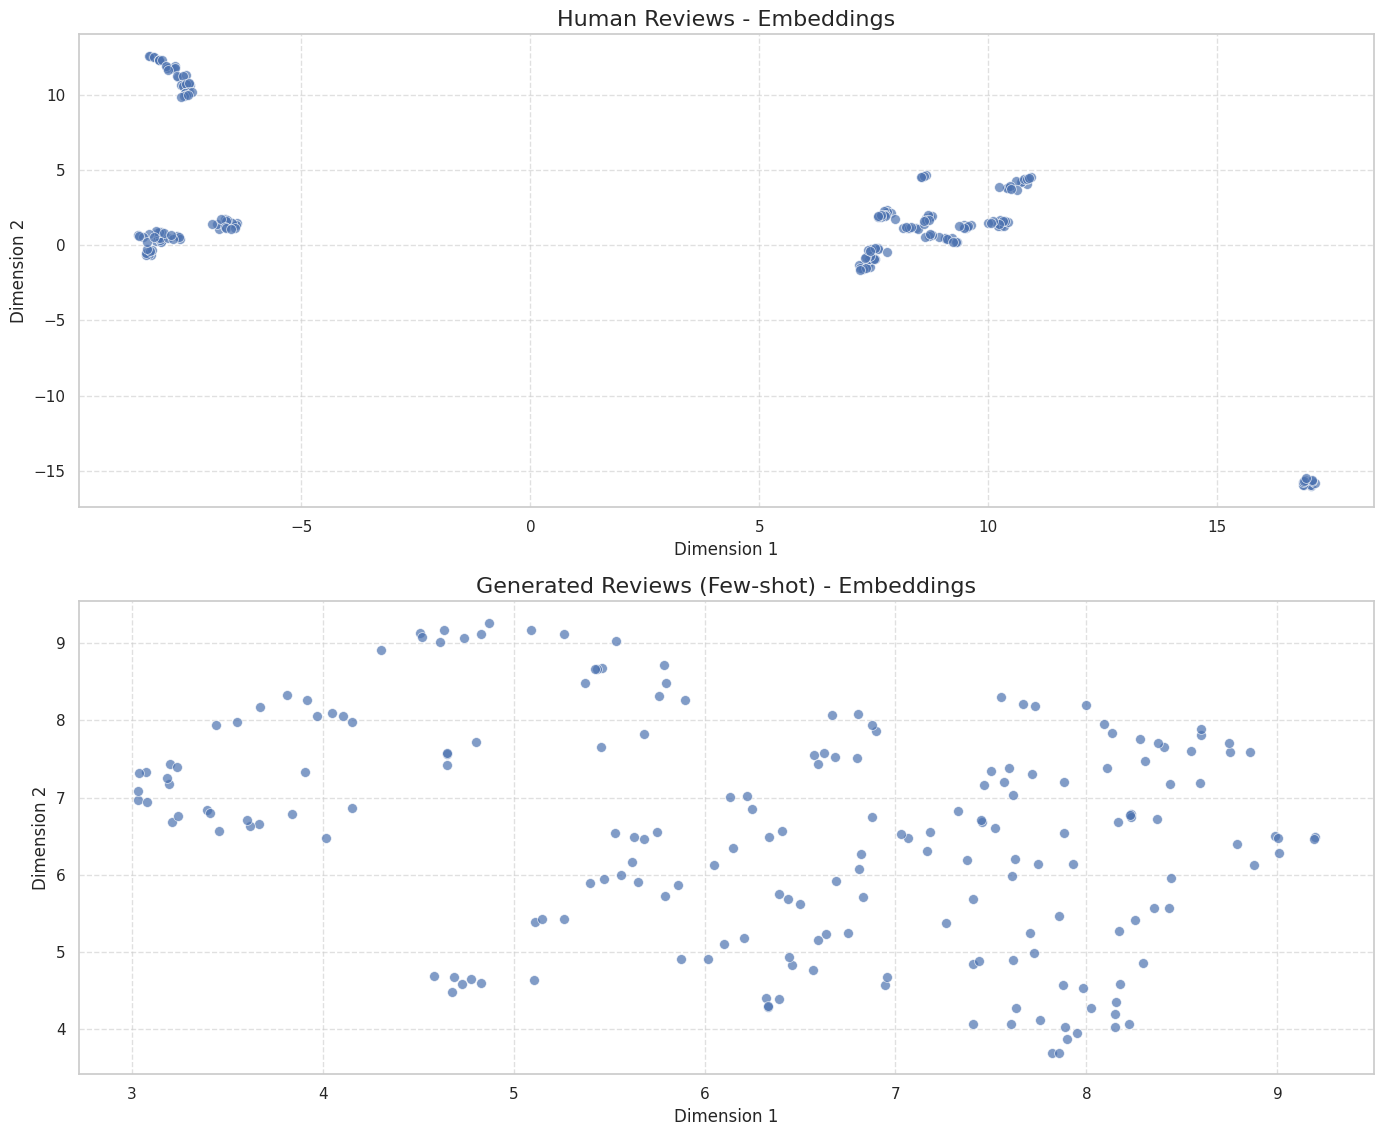

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 12))

# Plot for Human Reviews
plt.subplot(2, 1, 1)
sns.scatterplot(
    x=umap_embed_human[:, 0],
    y=umap_embed_human[:, 1],
    # hue=results_df['human_rating'],
    # palette='viridis',
    s=50,
    alpha=0.7,
    edgecolor='w',
    legend='full'
)
plt.title("Human Reviews - Embeddings", fontsize=16)
plt.xlabel("Dimension 1", fontsize=12)
plt.ylabel("Dimension 2", fontsize=12)
# plt.legend(title="Human Rating", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)


# Plot for Generated Reviews
plt.subplot(2, 1, 2)
sns.scatterplot(
    x=umap_embed_gen[:, 0],
    y=umap_embed_gen[:, 1],
    # hue=results_df['model'], # Color by the generated model
    # hue=results_df['ai_rating'].astype(int),
    # palette='viridis',
    s=50,
    alpha=0.7,
    edgecolor='w',
    legend='full'
)
plt.title("Generated Reviews (Few-shot) - Embeddings", fontsize=16)
plt.xlabel("Dimension 1", fontsize=12)
plt.ylabel("Dimension 2", fontsize=12)
# plt.legend(title="AI Rating", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(SAVE_DIR / "umap_embeddings.png", dpi=300)
plt.show()

# Style Embedding Similarity

In [31]:
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity

style_model = AutoModel.from_pretrained("AnnaWegmann/Style-Embedding")
tokenizer = AutoTokenizer.from_pretrained("AnnaWegmann/Style-Embedding")

def get_style_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        emb = style_model(**inputs).last_hidden_state.mean(dim=1)
    return emb.squeeze().numpy()

results_df["style_human"] = results_df["human_review"].apply(get_style_embedding)
results_df["style_gen"] = results_df["gen_review"].apply(get_style_embedding)
results_df["style_sim"] = results_df.apply(lambda x: cosine_similarity(
    [x["style_human"]], [x["style_gen"]])[0][0], axis=1)

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/354 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [32]:
print("Average style similarity:", results_df["style_sim"].mean())

Average style similarity: 0.9534503


# Per-Restaurant Aggregation

In [33]:
restaurant_summary = (
    results_df.groupby("restaurant")
      .agg({
          "cosine_sim": "mean",
          "semantic_similarity": "mean",
          "sentiment_diff": "mean"
      })
)
print(restaurant_summary.head())

                                     cosine_sim  semantic_similarity  \
restaurant                                                             
10 Downing Street                      0.145661             0.496650   
13 Dhaba                               0.122751             0.514097   
AB's - Absolute Barbecues              0.113354             0.519311   
Al Saba Restaurant                     0.117011             0.559700   
Banana Leaf Multicuisine Restaurant    0.098892             0.661983   

                                     sentiment_diff  
restaurant                                           
10 Downing Street                         -0.051282  
13 Dhaba                                  -0.244869  
AB's - Absolute Barbecues                  0.000616  
Al Saba Restaurant                         0.995760  
Banana Leaf Multicuisine Restaurant       -0.537113  


# Per-Model Aggregation

In [34]:
model_summary = (
    results_df.groupby("model")
      .agg({
          "cosine_sim": "mean",
          "semantic_similarity": "mean",
          "sentiment_diff": "mean",
          "style_sim": "mean"
      })
)
print(model_summary.head())

                   cosine_sim  semantic_similarity  sentiment_diff  style_sim
model                                                                        
codellama:latest     0.116276             0.567857        0.285088   0.952626
llama3.1:latest      0.155304             0.581559       -0.279539   0.956079
mistral:latest       0.125615             0.555912        0.359592   0.953068
qwen2.5-coder:32b    0.145309             0.533384        0.155350   0.952012


## Aggregate similarities by restaurant to detect model-specific biases.

In [35]:
restaurant_model_summary = (
    results_df.groupby(["restaurant", "model"])
    .agg({
        "cosine_sim": "mean",
        "semantic_similarity": "mean",
        "style_sim": "mean",
        "sentiment_diff": "mean"
    })
)

print(restaurant_model_summary.head(10))

                                             cosine_sim  semantic_similarity  \
restaurant                model                                                
10 Downing Street         codellama:latest     0.155577             0.521982   
                          llama3.1:latest      0.143717             0.519430   
                          mistral:latest       0.166929             0.536102   
                          qwen2.5-coder:32b    0.116420             0.409086   
13 Dhaba                  codellama:latest     0.172126             0.468270   
                          llama3.1:latest      0.138491             0.567711   
                          mistral:latest       0.114954             0.491896   
                          qwen2.5-coder:32b    0.065434             0.528511   
AB's - Absolute Barbecues codellama:latest     0.036168             0.464614   
                          llama3.1:latest      0.219496             0.627998   

                                       

# LLM-based Content Detection

In [36]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax

# Load detector model and tokenizer
detector_name = "roberta-base-openai-detector"
tokenizer = AutoTokenizer.from_pretrained(detector_name)
model = AutoModelForSequenceClassification.from_pretrained(detector_name)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at roberta-base-openai-detector were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [37]:
def detect_ai_generated(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = softmax(logits.numpy()[0])
    # Model output: index 0 = real, index 1 = fake (AI-generated)
    return {"real_prob": probs[0], "fake_prob": probs[1]}

### Detect AI Generated Text in Generated Reviews

In [38]:
results_df["detector_result_gen"] = results_df["gen_review"].apply(detect_ai_generated)
results_df["gen_real_prob"] = results_df["detector_result_gen"].apply(lambda x: x["real_prob"])
results_df["gen_fake_prob"] = results_df["detector_result_gen"].apply(lambda x: x["fake_prob"])

print(results_df[["gen_review", "gen_real_prob", "gen_fake_prob"]].head())

# compute mean fake probability
mean_fake_prob_gen = results_df["gen_fake_prob"].mean()
print(f"Average AI-detection probability (fake-generated): {mean_fake_prob_gen:.3f}")

                                          gen_review  gen_real_prob  \
0  fter a long day at work  was looking for a cal...       0.000168   
1  walked into komatose expecting a lively atmosp...       0.000174   
2  he soothing and calm ambiance of omatose at ol...       0.151691   
3  omatose at oliday nn xpress  uites offers a ca...       0.003024   
4  recently had a great experience at dipis pahar...       0.767378   

   gen_fake_prob  
0       0.999832  
1       0.999826  
2       0.848309  
3       0.996976  
4       0.232622  
Average AI-detection probability (fake-generated): 0.940


### Detect AI Generated Text in Human Reviews

In [39]:
human_reviews_df = results_df.drop_duplicates(subset=['human_review']).copy()
human_reviews_df["detector_result_human"] = human_reviews_df["human_review"].apply(detect_ai_generated)
human_reviews_df["human_real_prob"] = human_reviews_df["detector_result_human"].apply(lambda x: x["real_prob"])
human_reviews_df["human_fake_prob"] = human_reviews_df["detector_result_human"].apply(lambda x: x["fake_prob"])

print(human_reviews_df[["human_review", "human_real_prob", "human_fake_prob"]].head())

# compute mean fake probability
mean_fake_prob_human = human_reviews_df["human_fake_prob"].mean()
print(f"Average AI-detection probability (fake-human): {mean_fake_prob_human:.3f}")

                                         human_review  human_real_prob  \
0   the things which impressed me was the the cock...         0.008771   
4   ambience is okay but the food is good regular ...         0.333160   
8   environment was kinda boxed in which was not s...         0.024006   
12  great ambience and perfect roof top bar good s...         0.048278   
16  i was told by one of my colleague about this p...         0.000173   

    human_fake_prob  
0          0.991228  
4          0.666840  
8          0.975994  
12         0.951722  
16         0.999827  
Average AI-detection probability (fake-human): 0.919


# Per-Model Real/False Probability

In [40]:
model_prob = results_df.groupby("model").agg({"gen_fake_prob": "mean", "gen_real_prob": "mean"})
print(model_prob)

                   gen_fake_prob  gen_real_prob
model                                          
codellama:latest        0.946149       0.053851
llama3.1:latest         0.922917       0.077083
mistral:latest          0.937371       0.062629
qwen2.5-coder:32b       0.953690       0.046310


### Top 10 generated reviews classified as real

In [41]:
gen_prob_reviews = results_df[results_df['gen_real_prob'] > results_df['gen_fake_prob']][['model', 'gen_review', 'gen_real_prob',
                                                                                           'gen_fake_prob']]
gen_prob_reviews.sort_values(by='gen_real_prob', ascending=False).head(10)

,model,gen_review,gen_real_prob,gen_fake_prob
43,qwen2.5-coder:32b,unkin onuts surprised me with its delicious bu...,0.992698,0.007302
180,llama3.1:latest,visited frio bistro for their supposedly best ...,0.935429,0.064571
133,mistral:latest,he portions at oyal picy estaurant are simply ...,0.903365,0.096635
49,llama3.1:latest,dined at olive garden with family food was ave...,0.880968,0.119032
60,codellama:latest,recently visited 10 owning treet a general res...,0.847455,0.152545
30,mistral:latest,elightful array of unique ice cream flavors es...,0.833483,0.166517
4,codellama:latest,recently had a great experience at dipis pahar...,0.767378,0.232622
73,llama3.1:latest,had an interesting experience at 13 haba order...,0.605269,0.394731
5,llama3.1:latest,stumbled upon dipis pahar while exploring the ...,0.592393,0.407607


### Top 10 human reviews classified as fake

In [55]:
human_prob_reviews = human_reviews_df[human_reviews_df['human_fake_prob'] > human_reviews_df['human_real_prob']][['human_review', 'human_real_prob',
                                                                                           'human_fake_prob']]
human_prob_reviews.sort_values(by='human_fake_prob', ascending=False).head(10)

,human_review,human_real_prob,human_fake_prob
16,i was told by one of my colleague about this p...,0.000173,0.999827
147,having heard a lot about this place specially ...,0.000179,0.999821
84,second time being here its really beyond imagi...,0.000195,0.999805
163,i had visited this places multiple times and t...,0.000216,0.999784
155,visited this place several times for team lunc...,0.000218,0.999782
139,first impression when i looked at the box i wa...,0.000238,0.999762
80,this is bloody disgusting i had to wait for mo...,0.000325,0.999675
159,one of the best biryani i had in hyderabad amb...,0.000401,0.999599
183,such a disappointing visit went at around 730 ...,0.000430,0.999570
171,frio like unique name like unique place frio i...,0.000548,0.999452


# Visualize The Results

## Model Performance Comparison

Create bar charts to compare `cosine_sim`, `semantic_similarity`, `style_sim`, and `sentiment_diff` across different models.


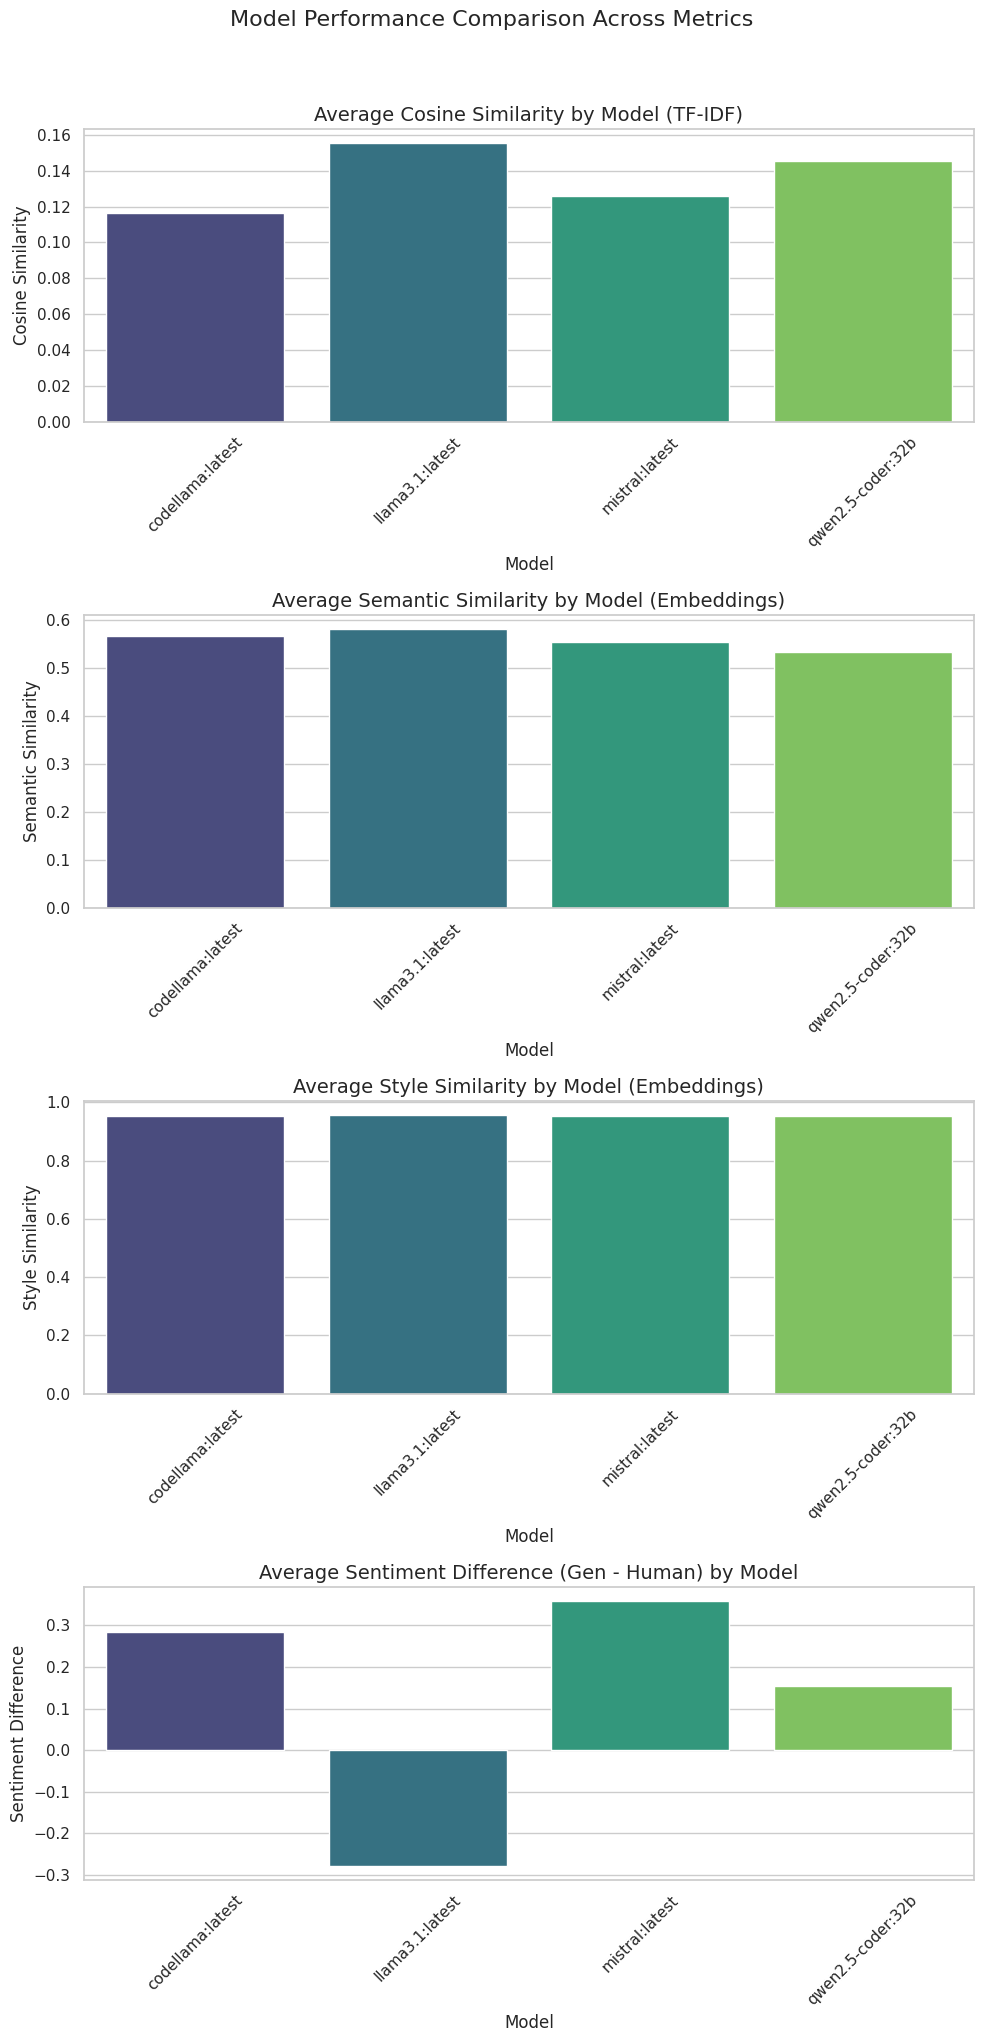

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
# Define the metrics to plot
metrics = ['cosine_sim', 'semantic_similarity', 'style_sim', 'sentiment_diff']
titles = {
    'cosine_sim': 'Average Cosine Similarity by Model (TF-IDF)',
    'semantic_similarity': 'Average Semantic Similarity by Model (Embeddings)',
    'style_sim': 'Average Style Similarity by Model (Embeddings)',
    'sentiment_diff': 'Average Sentiment Difference (Gen - Human) by Model'
}
ylabels = {
    'cosine_sim': 'Cosine Similarity',
    'semantic_similarity': 'Semantic Similarity',
    'style_sim': 'Style Similarity',
    'sentiment_diff': 'Sentiment Difference'
}

# Create subplots for each metric
fig, axes = plt.subplots(len(metrics), 1, figsize=(10, 5 * len(metrics)))
fig.suptitle('Model Performance Comparison Across Metrics', fontsize=16, y=1.02)

for i, metric in enumerate(metrics):
    sns.barplot(x=model_summary.index, y=model_summary[metric], hue=model_summary.index, ax=axes[i], palette='viridis', legend=False)
    axes[i].set_title(titles[metric], fontsize=14)
    axes[i].set_xlabel('Model', fontsize=12)
    axes[i].set_ylabel(ylabels[metric], fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(SAVE_DIR / "model_performance_comparison.png", dpi=300)
plt.show()

The bar charts above visualize the average performance of each language model across several key metrics:

- **Average Cosine Similarity**: Measures the lexical overlap between generated and human reviews. A higher value indicates more similar wording.
- **Average Semantic Similarity**: Assesses the underlying meaning similarity between generated and human reviews, using BERT-based embeddings. Higher values suggest the generated reviews capture the essence of human reviews better.
- **Average Style Similarity**: Compares the stylistic resemblance between generated and human reviews. Higher values imply the generated text mimics the writing style of human reviews more closely.
- **Average Sentiment Difference (Gen - Human)**: Indicates the average difference in sentiment scores between generated and human reviews. Positive values mean generated reviews are more positive, while negative values mean they are more negative than human reviews.

# Readability Comparison

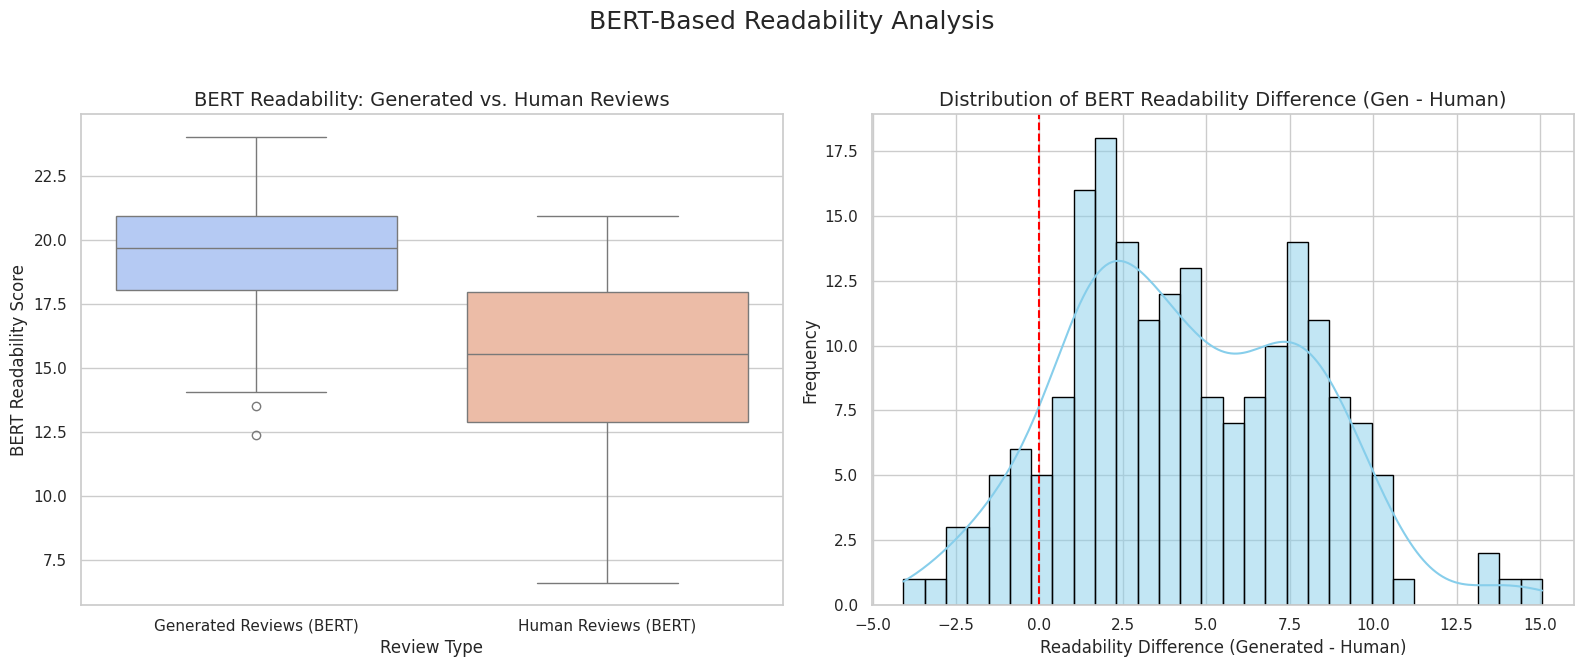

In [45]:
sns.set_theme(style="whitegrid")

# Prepare data for box plot comparing generated and human BERT readability
bert_readability_data = results_df[['readability_gen_bert', 'readability_human_bert']].melt(
    var_name='Review Type',
    value_name='BERT Readability Score'
)
bert_readability_data['Review Type'] = bert_readability_data['Review Type'].replace({
    'readability_gen_bert': 'Generated Reviews (BERT)',
    'readability_human_bert': 'Human Reviews (BERT)'
})

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('BERT-Based Readability Analysis', fontsize=18)

# Box Plot for Generated vs. Human BERT Readability
sns.boxplot(
    x='Review Type',
    y='BERT Readability Score',
    data=bert_readability_data,
    hue='Review Type',
    palette='coolwarm',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('BERT Readability: Generated vs. Human Reviews', fontsize=14)
axes[0].set_xlabel('Review Type', fontsize=12)
axes[0].set_ylabel('BERT Readability Score', fontsize=12)

# Histogram for BERT Readability Difference
sns.histplot(
    results_df['readability_diff_bert'].dropna(),
    bins=30,
    kde=True,
    ax=axes[1],
    color='skyblue',
    edgecolor='black'
)
axes[1].set_title('Distribution of BERT Readability Difference (Gen - Human)', fontsize=14)
axes[1].set_xlabel('Readability Difference (Generated - Human)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].axvline(0, color="red", linestyle="--")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(SAVE_DIR / "bert_readability_analysis.png", dpi=300)
plt.show()

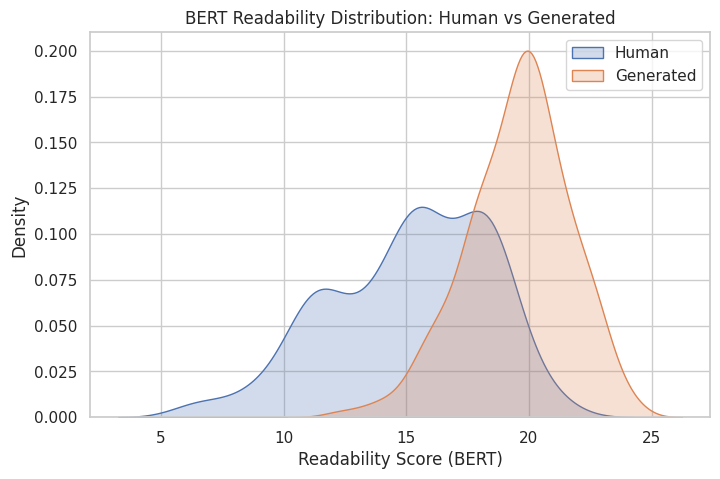

In [46]:
plt.figure(figsize=(8,5))
sns.kdeplot(results_df["readability_human_bert"], fill=True, label="Human")
sns.kdeplot(results_df["readability_gen_bert"], fill=True, label="Generated")
plt.title("BERT Readability Distribution: Human vs Generated")
plt.xlabel("Readability Score (BERT)")
plt.ylabel("Density")
plt.legend()
plt.savefig(SAVE_DIR / "bert_readability_distribution.png", dpi=300)
plt.show()

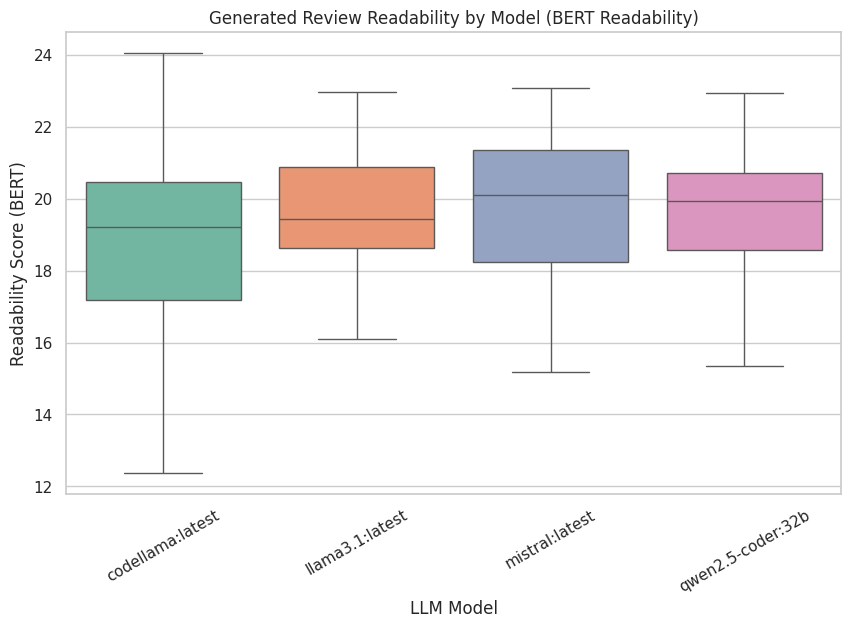

In [47]:
plt.figure(figsize=(10,6))
sns.boxplot(data=results_df, x="model", y="readability_gen_bert", palette="Set2", hue="model", legend=False)
plt.title("Generated Review Readability by Model (BERT Readability)")
plt.xlabel("LLM Model")
plt.ylabel("Readability Score (BERT)")
plt.xticks(rotation=30)
plt.savefig(SAVE_DIR / "bert_readability_by_model.png", dpi=300)
plt.show()

### Average AI-Detection Probability by Model
Create a bar chart to show the average AI-detection probability (`gen_fake_prob`) for each model.


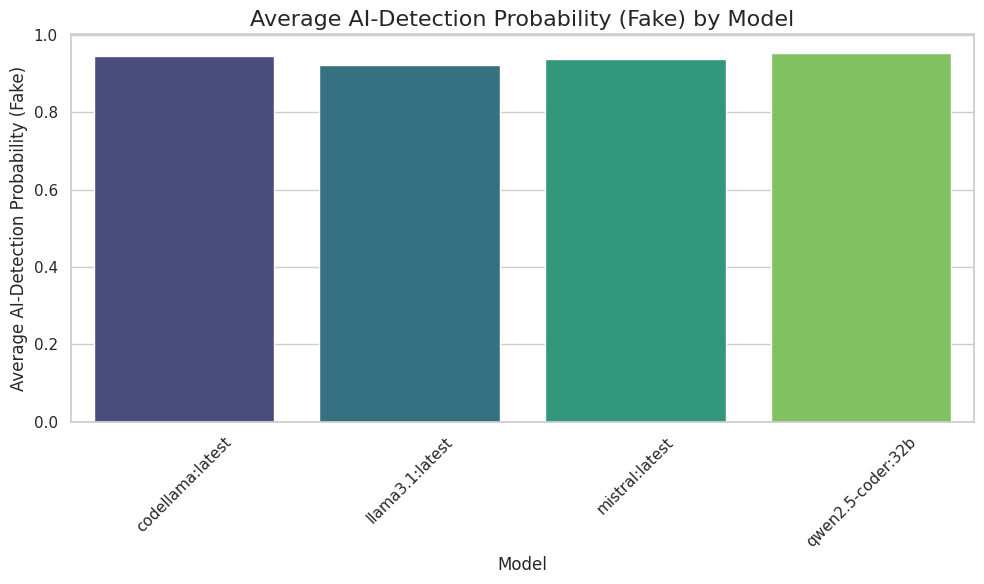

In [48]:
plt.figure(figsize=(10, 6))
sns.barplot(x=model_prob.index, y=model_prob['gen_fake_prob'], hue=model_prob.index, palette='viridis', legend=False)
plt.title('Average AI-Detection Probability (Fake) by Model', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Average AI-Detection Probability (Fake)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(SAVE_DIR / "ai_detection_probability_by_model.png", dpi=300)
plt.show()

### Distribution of Similarity Metrics
Create histograms to show the distribution of `cosine_sim` and `semantic_similarity`.

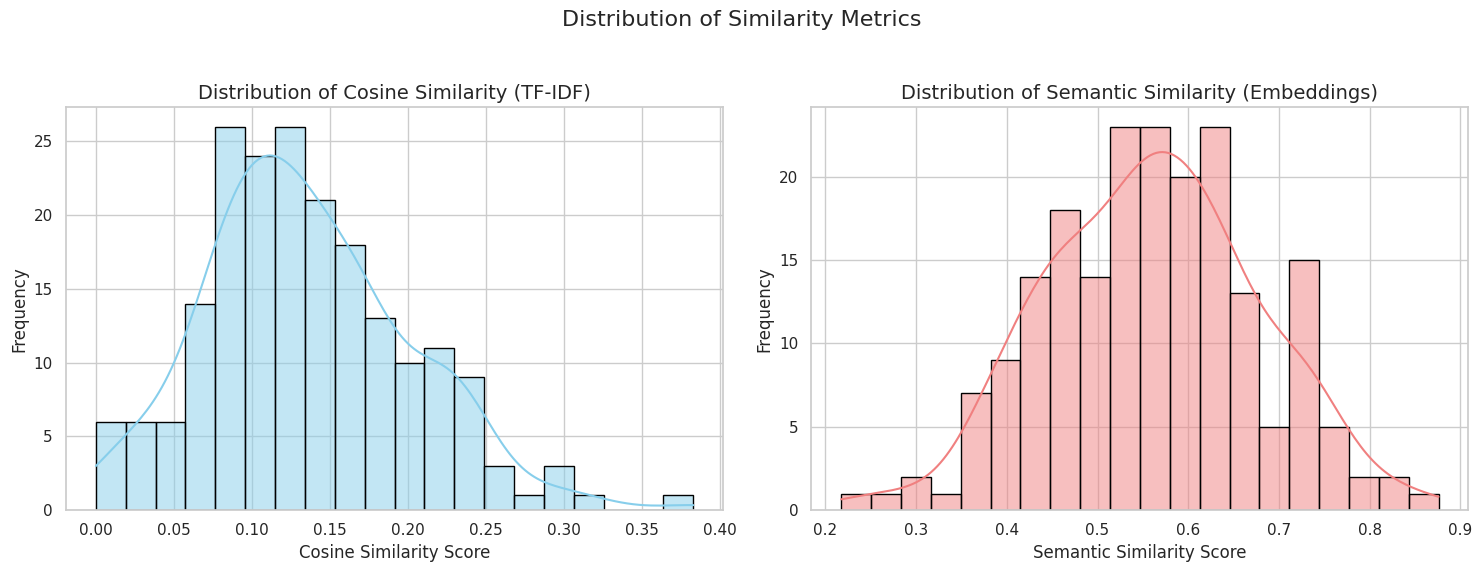

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Distribution of Similarity Metrics', fontsize=16)

# Histogram for Cosine Similarity
sns.histplot(results_df['cosine_sim'], bins=20, kde=True, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Cosine Similarity (TF-IDF)', fontsize=14)
axes[0].set_xlabel('Cosine Similarity Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# Histogram for Semantic Similarity
sns.histplot(results_df['semantic_similarity'], bins=20, kde=True, ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Distribution of Semantic Similarity (Embeddings)', fontsize=14)
axes[1].set_xlabel('Semantic Similarity Score', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(SAVE_DIR / "similarity_distribution.png", dpi=300)
plt.show()

### Compare AI-Detection Probability for Generated vs. Human Reviews
Create histograms to compare `gen_fake_prob` and `human_fake_prob` from `results_df`.

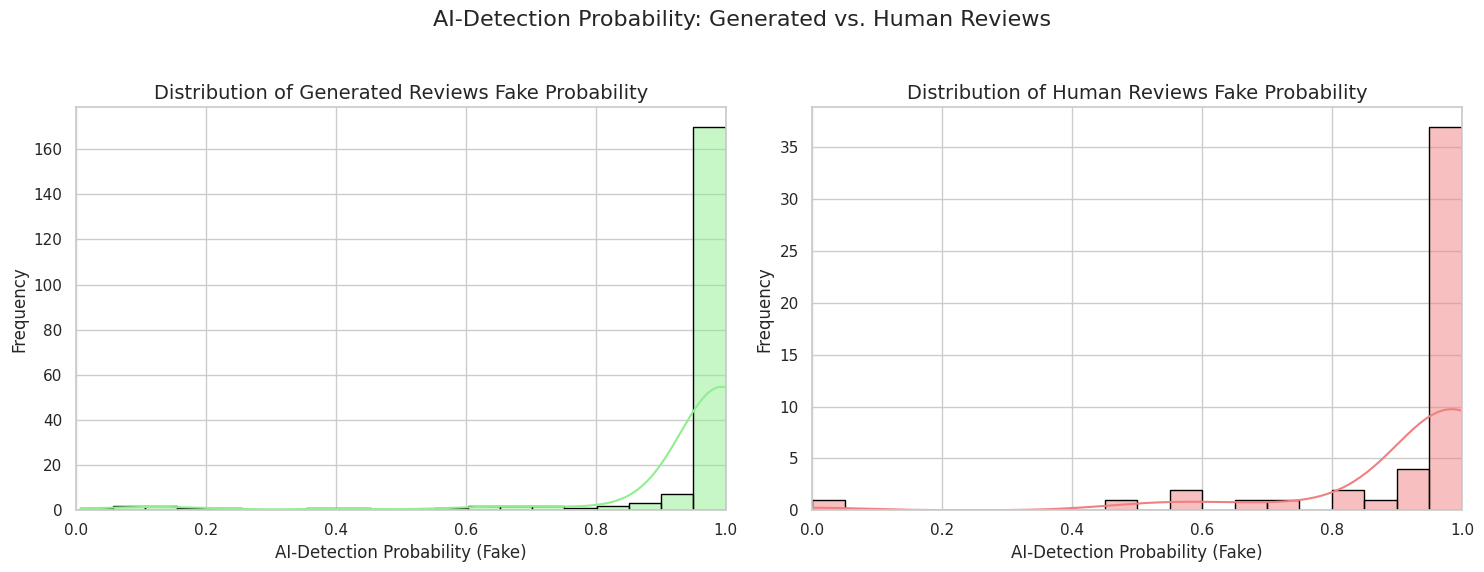

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('AI-Detection Probability: Generated vs. Human Reviews', fontsize=16)

# Histogram for Generated Fake Probability
sns.histplot(results_df['gen_fake_prob'], bins=20, kde=True, ax=axes[0], color='lightgreen', edgecolor='black')
axes[0].set_title('Distribution of Generated Reviews Fake Probability', fontsize=14)
axes[0].set_xlabel('AI-Detection Probability (Fake)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_xlim(0, 1) # Probability range

# Histogram for Human Fake Probability
sns.histplot(human_reviews_df['human_fake_prob'], bins=20, kde=True, ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Distribution of Human Reviews Fake Probability', fontsize=14)
axes[1].set_xlabel('AI-Detection Probability (Fake)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_xlim(0, 1) # Probability range

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Summary:

### Data Analysis Key Findings

*   **Model Performance across Metrics:**
    *   Bar charts were generated to compare average `cosine_sim`, `semantic_similarity`, `style_sim`, and `sentiment_diff` across different models, illustrating their varied performance in lexical, semantic, and stylistic similarity, as well as sentiment alignment with human reviews.
*   **Average AI-Detection Probability:**
    *   A bar chart was created showing the average AI-detection probability (`gen_fake_prob`) for each model, indicating how likely generated reviews from each model are to be flagged as AI-generated.
*   **Distribution of Similarity Metrics:**
    *   Histograms revealed the distribution of `cosine_sim` and `semantic_similarity` across all generated reviews, providing insights into the overall range and frequency of these similarity scores.
*   **Correlation between Rating and Generated Sentiment:**
    *   A scatter plot with a regression line visualized the relationship between the `rating` of the original review and the `sentiment_gen` of the generated review, suggesting how well models align sentiment with star ratings.
*   **Readability Comparison:**
    *   Box plots compared the Flesch Reading Ease scores for `readability_gen` (generated reviews) and `readability_human` (human reviews), highlighting differences in readability levels.
*   **AI-Detection Probability for Generated vs. Human Reviews:**
    *   Histograms showcased the distribution of AI-detection probabilities for both `gen_fake_prob` and `human_fake_prob`, allowing for a direct comparison of how detectable AI-generated content is versus human-written content.


## Analyze AI vs Human Ratings

Calculate descriptive statistics and correlation between 'ai_rating' and 'human_rating' from 'results_df'.


In [52]:
print("Descriptive statistics for AI Rating:\n", results_df['ai_rating'].describe())
print("\nDescriptive statistics for Human Rating:\n", results_df['human_rating'].describe())

correlation = results_df['ai_rating'].corr(results_df['human_rating'])
print(f"\nPearson correlation between AI Rating and Human Rating: {correlation:.3f}")

Descriptive statistics for AI Rating:
 count    199.000000
mean       3.386432
std        1.225968
min        1.000000
25%        2.050000
50%        3.900000
75%        4.000000
max        5.000000
Name: ai_rating, dtype: float64

Descriptive statistics for Human Rating:
 count    199.000000
mean       3.150754
std        1.650646
min        1.000000
25%        1.000000
50%        4.000000
75%        5.000000
max        5.000000
Name: human_rating, dtype: float64

Pearson correlation between AI Rating and Human Rating: 0.445


## Visualize Rating Distributions

Create histograms for 'ai_rating' and 'human_rating' to understand their individual distributions.


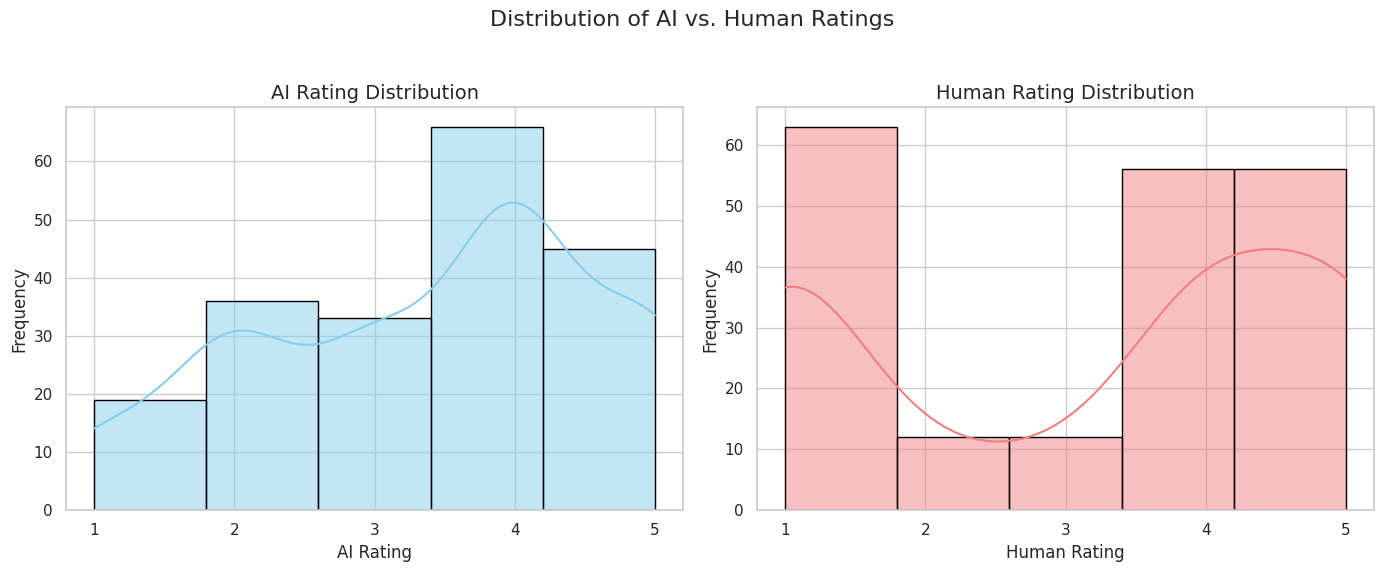

In [53]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribution of AI vs. Human Ratings', fontsize=16)

# Histogram for AI Rating
sns.histplot(results_df['ai_rating'], bins=5, kde=True, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('AI Rating Distribution', fontsize=14)
axes[0].set_xlabel('AI Rating', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_xticks([1, 2, 3, 4, 5])

# Histogram for Human Rating
sns.histplot(results_df['human_rating'], bins=5, kde=True, ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Human Rating Distribution', fontsize=14)
axes[1].set_xlabel('Human Rating', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_xticks([1, 2, 3, 4, 5])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(SAVE_DIR / "rating_distribution.png", dpi=300)
plt.show()

## Visualize Rating Difference

Calculate the difference between 'ai_rating' and 'human_rating' and visualize its distribution.


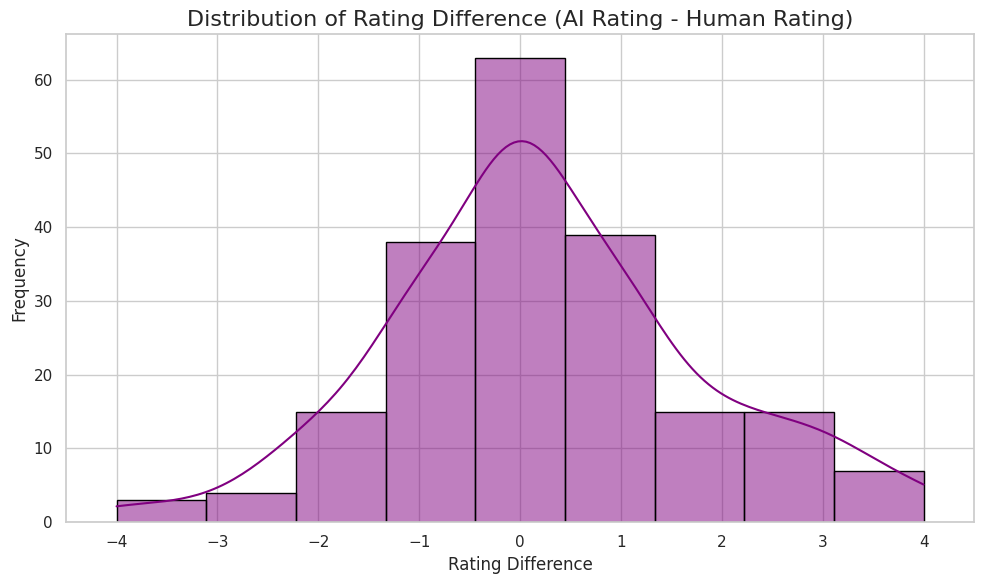

In [54]:
results_df['rating_difference'] = results_df['ai_rating'] - results_df['human_rating']

plt.figure(figsize=(10, 6))
sns.histplot(results_df['rating_difference'], bins=9, kde=True, color='purple', edgecolor='black')
plt.title('Distribution of Rating Difference (AI Rating - Human Rating)', fontsize=16)
plt.xlabel('Rating Difference', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(range(-4, 5))
plt.xlim(-4.5, 4.5)
plt.tight_layout()
plt.savefig(SAVE_DIR / "rating_difference_distribution.png", dpi=300)
plt.show()

## Summary:

### Data Analysis Key Findings

*   **Descriptive Statistics for Ratings:**
    *   AI ratings have a mean of approximately 3.39 (std dev: 1.23) and a median of 3.90.
    *   Human ratings have a mean of approximately 3.15 (std dev: 1.65) and a median of 4.0.
    *   Both AI and human ratings range from 1 to 5.
    *   Human ratings exhibit a wider spread (higher standard deviation) compared to AI ratings, suggesting greater variability in human assessments.
*   **Correlation between Ratings:** A Pearson correlation coefficient of 0.445 was found between AI and human ratings, indicating a moderate positive linear relationship.
*   **Distribution of AI Ratings:** The histogram for AI ratings shows a distribution skewed towards higher ratings, with a concentration around 4.
*   **Distribution of Human Ratings:** The histogram for human ratings appears to be less symmetric, potentially showing multiple peaks or a less consistent pattern than AI ratings, with a noticeable presence of both low (1) and high (4-5) ratings.
*   **Rating Differences:** The distribution of the difference between AI and human ratings (AI Rating - Human Rating) shows a range from -4 to 4. The positive mean difference (3.386 - 3.151 = 0.235) suggests that AI tends to rate slightly higher on average than humans.
